In [1]:
# dataset: Mall customers.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [4]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### create input data

In [6]:
x = df.iloc[:,[3,4]]

In [7]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### Visualize the data

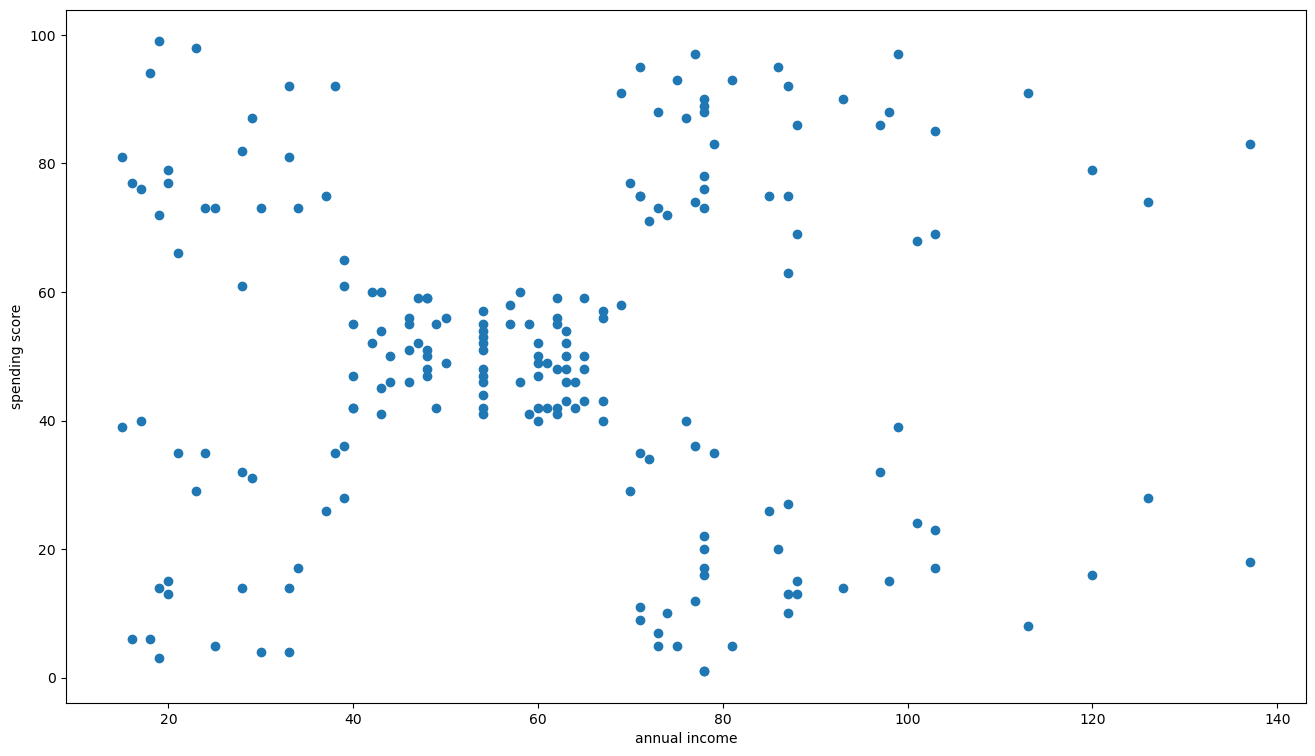

In [10]:
plt.figure(figsize=(16,9))
plt.xlabel('annual income')
plt.ylabel('spending score')
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)']);

#### Build the model

In [19]:
from sklearn.cluster import KMeans

In [20]:
km = KMeans(n_clusters= 3, random_state= 0 )

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [22]:
labels = km.fit_predict(x)

In [23]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [24]:
# sum squared error (SSE)
km.inertia_

106348.37306211122

In [27]:
sse = []
for k in range(1,16):
    km = KMeans(n_clusters= k, random_state= 0 )
    km.fit_predict(x)
    sse.append(km.inertia_)

In [28]:
sse

[269981.28,
 181363.59595959593,
 106348.37306211122,
 73679.78903948836,
 44448.4554479337,
 37265.86520484346,
 30259.65720728547,
 25050.832307547527,
 21862.092672182895,
 19657.78360870395,
 17584.589416163646,
 16032.113097679265,
 14523.258112983116,
 13000.92742551566,
 12072.54244921745]

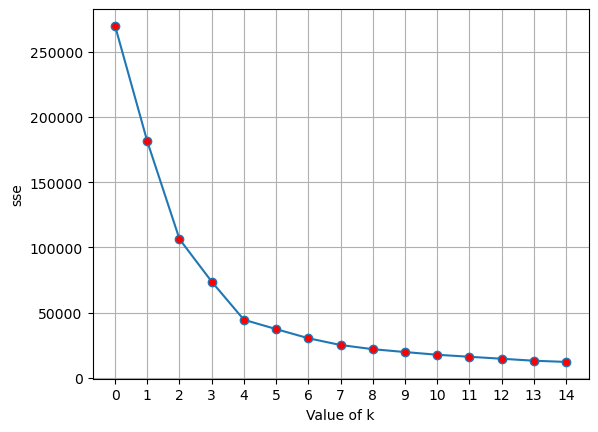

In [31]:
plt.xlabel('Value of k')
plt.ylabel('sse')
plt.xticks(range(0,17,1))
plt.plot(sse, marker = 'o', mfc = 'r');
plt.grid()

In [32]:
# !pip install kneed

In [33]:
from kneed import KneeLocator

In [34]:
kl = KneeLocator(range(1,16), sse, curve = 'convex', 
                 direction= 'decreasing')

In [35]:
kl.elbow

5

### Silhouette method

In [36]:
from sklearn.metrics import silhouette_score

In [41]:
silh = []
for k in range(2,16):
    km = KMeans(n_clusters= k, random_state= 0 )
    labels = km.fit_predict(x)
    score = silhouette_score(x, labels)
    silh.append(score)

In [42]:
silh

[0.2968969162503008,
 0.46761358158775435,
 0.4931963109249047,
 0.553931997444648,
 0.5379675585622219,
 0.5264283703685728,
 0.45544193969058644,
 0.4553729779390266,
 0.44760979994374317,
 0.4472950813160941,
 0.4323888233160193,
 0.4309886380247191,
 0.4202217866258089,
 0.4234508184777198]

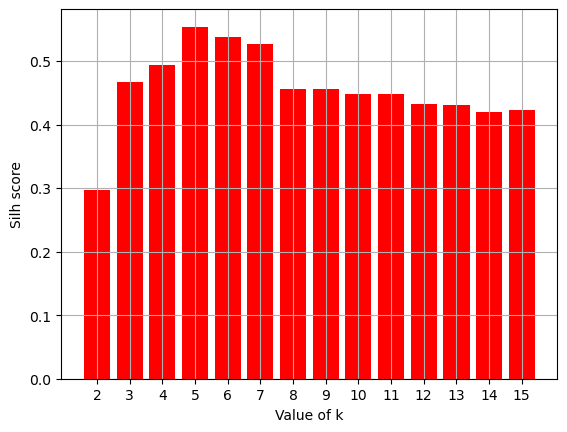

In [43]:
plt.xlabel('Value of k')
plt.ylabel('Silh score')
plt.xticks(range(2, 16))
plt.bar(range(2,16), silh, color = 'r')
plt.grid();

In [44]:
km = KMeans(random_state=0, n_clusters = 5)

In [45]:
labels = km.fit_predict(x)

In [46]:
labels

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [47]:
km.inertia_

44448.4554479337

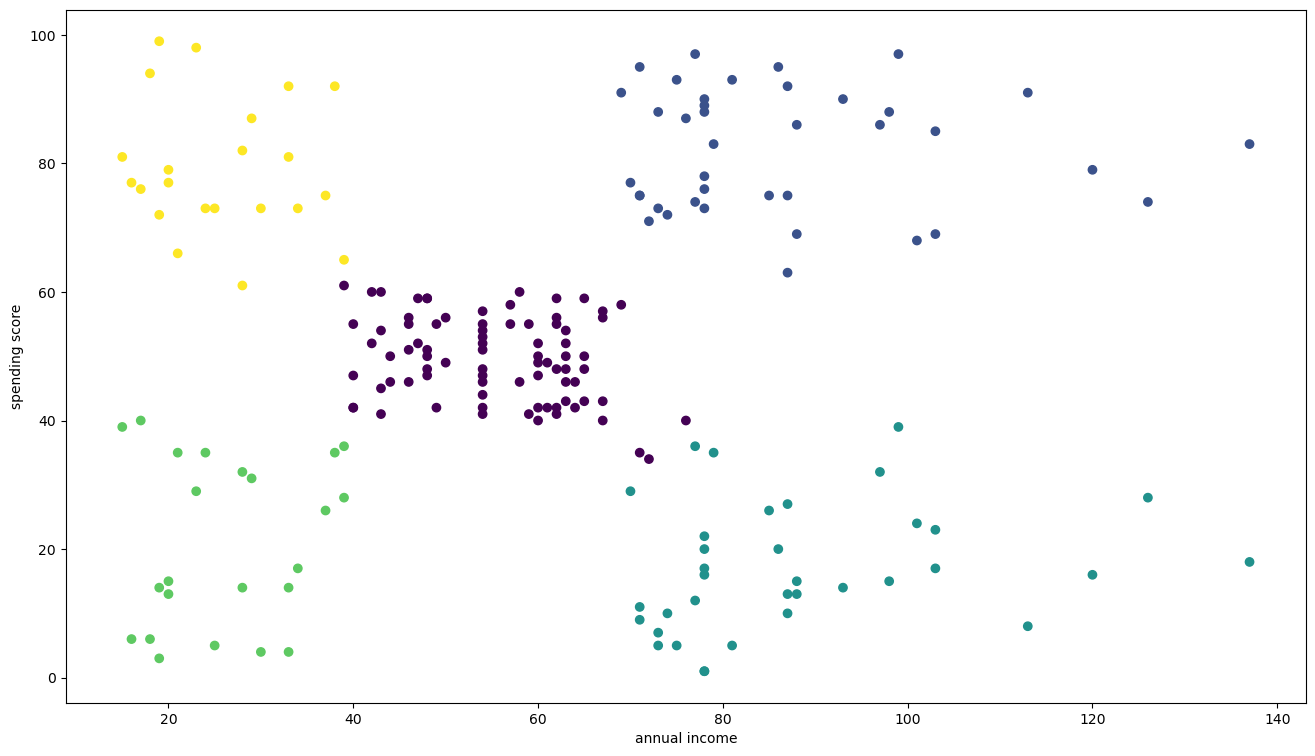

In [48]:
plt.figure(figsize=(16,9))
plt.xlabel('annual income')
plt.ylabel('spending score')
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
           c =labels);

### Filter out the clusters

In [49]:
zero = df[labels == 0]

In [50]:
zero.shape

(81, 5)

In [51]:
one = df[labels == 1]
two = df[labels == 2]
three = df[labels == 3]
four = df[labels == 4]

In [54]:
one.shape

(39, 5)

In [56]:
two.shape

(35, 5)

In [57]:
three.shape, four.shape

((23, 5), (22, 5))

### prediction on new data

In [58]:
new1  = [[45, 67]]
new2 = [[15, 51]]

In [59]:
km.predict(new1)

array([0], dtype=int32)

In [60]:
km.predict(new2)

array([4], dtype=int32)